# Lab 7- Data Analysis


## Exercise 1: Reading

### HiggsML
In 2014, some of my colleagues from the ATLAS experiment put together a Higgs Machine Learning Challenge, which was hosted on [Kaggle](https://www.kaggle.com). Please read sections 1 and 3 (skip/skim 2) of [The HiggsML Technical Documentation](https://higgsml.lal.in2p3.fr/files/2014/04/documentation_v1.8.pdf). 

Kaggle is a platform for data science competitions, with cash awards for winners. Kaggle currently hosts over 50,000 public datasets and associated competitions. Later in the course we will look at a variety of problems hosted on Kaggle and similar platforms. 

### SUSY Dataset

For the next few labs we will use datasets used in the [first paper on Deep Learning in High Energy physics](https://arxiv.org/pdf/1402.4735.pdf). Please read up to the "Deep Learning" section (end of page 5). This paper demonstrates that Deep Neural Networks can learn from raw data the features that are typically used by physicists for searches for exotics particles. The authors provide the data they used for this paper. They considered two benchmark scenarios: Higgs and SUSY.

## Exercise 2: Download SUSY Dataset

The information about the dataset can be found at the [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/index.php). We'll start with the [SUSY Dataset](https://archive.ics.uci.edu/ml/datasets/SUSY). 

### Download
In a terminal, download the data directly from the source and then decompress it. For example:

* To download:
    * On Mac OS: 
    `curl http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz > SUSY.csv.gz`

    * In linux:
    `wget http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz`

* To uncompress:
`gunzip SUSY.csv.gz`

In [1]:
!curl http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz > SUSY.csv.gz

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0   0     0   0     0     0     0  --:--:-- --:--:-- --:--:--     0
  0     0   0     0   0     0     0     0  --:--:--  0:00:01 --:--:--     0
  0     0   0     0   0     0     0     0  --:--:--  0:00:02 --:--:--     0
  0     0   0     0   0     0     0     0  --:--:--  0:00:03 --:--:--     0
  0     0   0     0   0     0     0     0  --:--:--  0:00:04 --:--:--     0
  0     0   0     0   0     0     0     0  --:--:--  0:00:05 --:--:--     0
  0     0   0     0   0     0     0     0  --:--:--  0:00:06 --:--:--     0
  0     0   0     0   0     0     0     0  --:--:--  0:00:07 --:--:--     0
  0     0   0     0   0     0     0     0  --:--:--  0:00:08 --:--:--     0
  0     0   0     0   0     0     0     0  --:--:--  0:00:09 --:--:--     0
  0     0   0     0   0     0     0     0  --:--:--  0:00:10 --:--:--     0
  0  

In [2]:
!rm SUSY.csv

In [3]:
!gunzip SUSY.csv.gz

'gunzip' is not recognized as an internal or external command,
operable program or batch file.


In [4]:
ls -lh

 Volume in drive C has no label.
 Volume Serial Number is 52E4-D61F

 Directory of C:\Users\Renuka\Desktop\python-from-hell\DATA3402.Spring.2026\Labs\Lab.7



File Not Found


The data is provided as a comma separated file.

In [ ]:
import os

# delete bad/incomplete files if they exist
for file in ["SUSY.csv.gz", "SUSY.csv"]:
    if os.path.exists(file):
        os.remove(file)
        print(file, "deleted")
    else:
        print(file, "not found")
df.head()

In [ ]:
import urllib.request
import gzip
import shutil

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz"

# download again
urllib.request.urlretrieve(url, "SUSY.csv.gz")
print("Download complete")

# unzip it into SUSY.csv
with gzip.open("SUSY.csv.gz", "rb") as f_in:
    with open("SUSY.csv", "wb") as f_out:
        shutil.copyfileobj(f_in, f_out)

print("Unzipped complete")

In [ ]:
import pandas as pd

df = pd.read_csv("SUSY.csv", header=None)
df.head()

## Reducing the dataset

This is a rather large dataset. If you have trouble loading it, we can easily make a new file with less data.

Here we look at the size of the data

In [6]:
!ls -lh

total 281M
-rw-r--r-- 1 Renuka 197609 229M Apr  4 00:56 SUSY-small.csv
-rw-r--r-- 1 Renuka 197609  53M Apr 27 13:25 SUSY.csv.gz
-rw-r--r-- 1 Renuka 197609  40K Apr 27 13:25 lab7_Finished.ipynb


We see that we have 5 million datapoints.

In [4]:
!wc -l SUSY.csv

5000000 SUSY.csv


We create a new file of the first half million. This is sufficient for our needs in this lab:

In [5]:
!head -500000 SUSY.csv > SUSY-small.csv

In [6]:
ls -lh

 Volume in drive C has no label.
 Volume Serial Number is 52E4-D61F

 Directory of C:\Users\Renuka\Desktop\python-from-hell\DATA3402.Spring.2026\Labs\Lab.7



File Not Found


In [7]:
! wc -l SUSY-small.csv

500000 SUSY-small.csv


Use this file for the rest of the lab to make this run faster.

### First Look

Each row represents a LHC collision event. Each column contains some observable from that event. The variable names are ([based on documentation](https://archive.ics.uci.edu/ml/datasets/SUSY)):

In [8]:
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", 
          "l_2_eta", "l_2_phi", "MET", "MET_phi", "MET_rel",
          "axial_MET", "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R",
          "dPhi_r_b", "cos_theta_r1"]

Some of these variables represent the "raw" kinematics of the observed final state particles, while others are "features" that are derived from these raw quantities:

In [9]:
RawNames=["l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta",
          "l_2_phi", "MET", "MET_phi"]
FeatureNames=list(set(VarNames[1:]).difference(RawNames))

In [10]:
RawNames

['l_1_pT',
 'l_1_eta',
 'l_1_phi',
 'l_2_pT',
 'l_2_eta',
 'l_2_phi',
 'MET',
 'MET_phi']

In [11]:
FeatureNames

['MT2',
 'M_Delta_R',
 'M_R',
 'MET_rel',
 'cos_theta_r1',
 'R',
 'S_R',
 'axial_MET',
 'dPhi_r_b',
 'M_TR_2']

We will use pandas to read in the file, and matplotlib to make plots. The following ensures pandas is installed and sets everything up:

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

Now we can read the data into a pandas dataframe:

In [13]:
filename = "SUSY.csv"
df = pd.read_csv(filename, dtype='float64', names=VarNames)

You can see the data in Jupyter by just evaluateing the dataframe:

In [14]:
df

,signal,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
0,0.0,0.972861,0.653855,1.176225,1.157156,-1.739873,-0.874309,0.567765,-0.175000,0.810061,-0.252552,1.921887,0.889637,0.410772,1.145621,1.932632,0.994464,1.367815,0.040714
1,1.0,1.667973,0.064191,-1.225171,0.506102,-0.338939,1.672543,3.475464,-1.219136,0.012955,3.775174,1.045977,0.568051,0.481928,0.000000,0.448410,0.205356,1.321893,0.377584
2,1.0,0.444840,-0.134298,-0.709972,0.451719,-1.613871,-0.768661,1.219918,0.504026,1.831248,-0.431385,0.526283,0.941514,1.587535,2.024308,0.603498,1.562374,1.135454,0.180910
3,1.0,0.381256,-0.976145,0.693152,0.448959,0.891753,-0.677328,2.033060,1.533041,3.046260,-1.005285,0.569386,1.015211,1.582217,1.551914,0.761215,1.715464,1.492257,0.090719
4,1.0,1.309996,-0.690089,-0.676259,1.589283,-0.693326,0.622907,1.087562,-0.381742,0.589204,1.365479,1.179295,0.968218,0.728563,0.000000,1.083158,0.043429,1.154854,0.094859
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4999995,1.0,0.853325,-0.961783,-1.487277,0.678190,0.493580,1.647969,1.843867,0.276954,1.025105,-1.486535,0.892879,1.684429,1.674084,3.366298,1.046707,2.646649,1.389226,0.364599
4999996,0.0,0.951581,0.139370,1.436884,0.880440,-0.351948,-0.740852,0.290863,-0.732360,0.001360,0.257738,0.802871,0.545319,0.602730,0.002998,0.748959,0.401166,0.443471,0.239953
4999997,0.0,0.840389,1.419162,-1.218766,1.195631,1.695645,0.663756,0.490888,-0.509186,0.704289,0.045744,0.825015,0.723530,0.778236,0.752942,0.838953,0.614048,1.210595,0.026692
4999998,1.0,1.784218,-0.833565,-0.560091,0.953342,-0.688969,-1.428233,2.660703,-0.861344,2.116892,2.906151,1.232334,0.952444,0.685846,0.000000,0.781874,0.676003,1.197807,0.093689


The first column stores the "truth" label of whether an event was signal or not. Pandas makes it easy to create dataframes that store only the signal or background events:

In [15]:
df_sig=df[df.signal==1]
df_bkg=df[df.signal==0]

The following example plots the signal and background distributions of every variable. Note that we use VarNames[1:] to skip the first variable, which was the true label.

l_1_pT


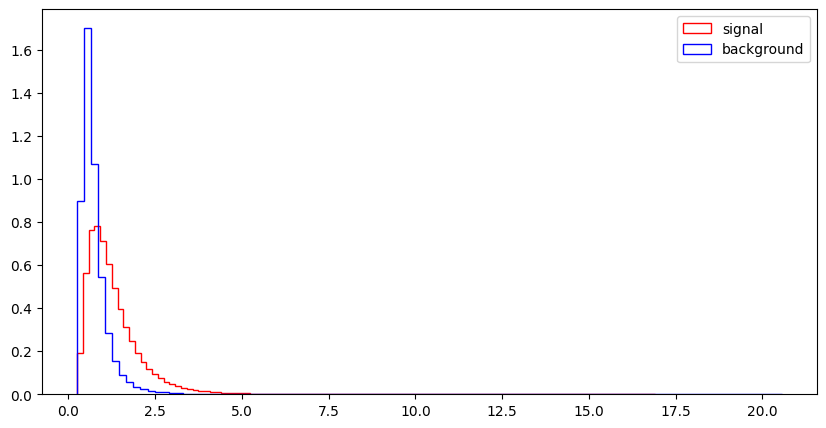

l_1_eta


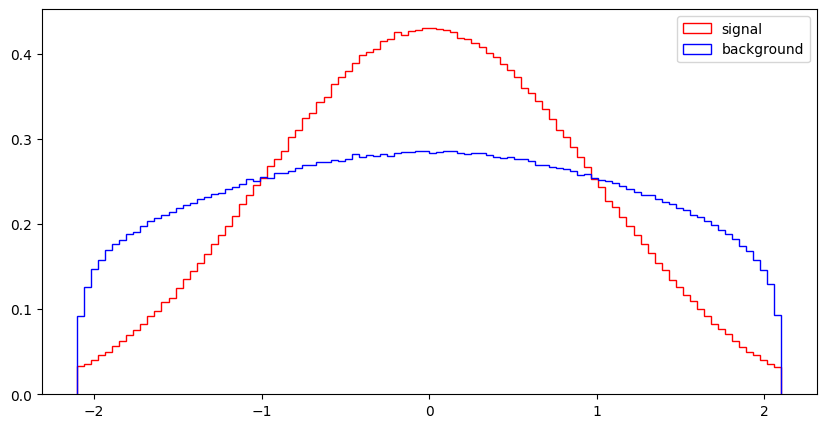

l_1_phi


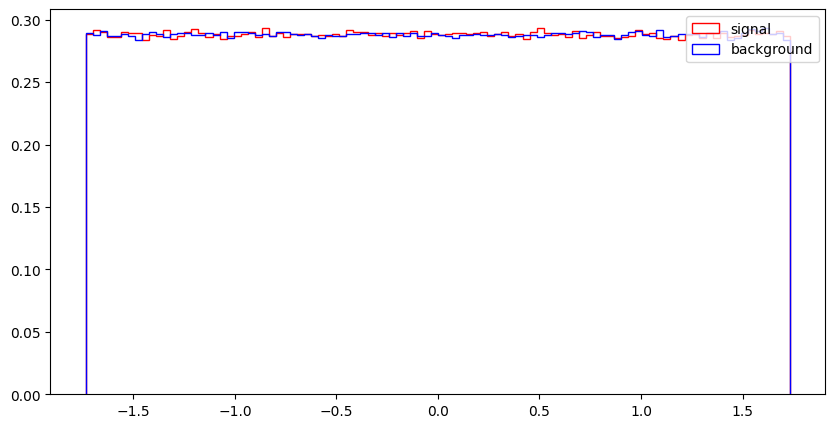

l_2_pT


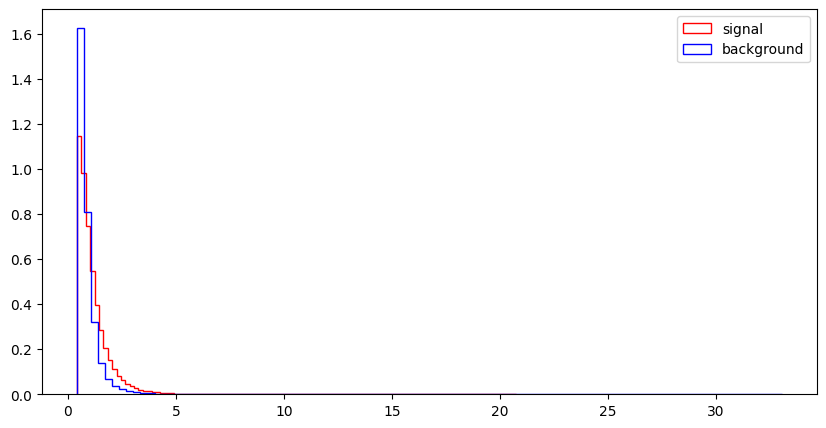

l_2_eta


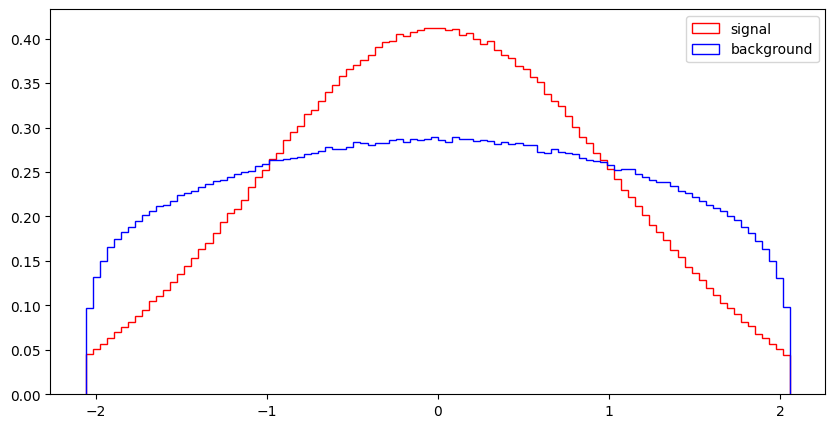

l_2_phi


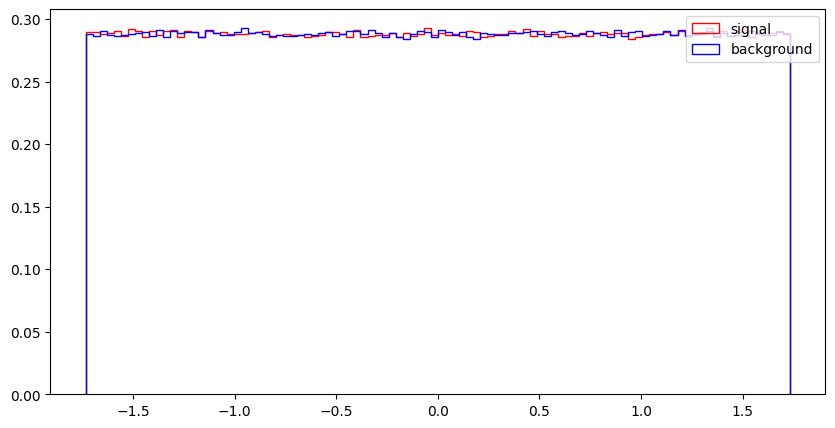

MET


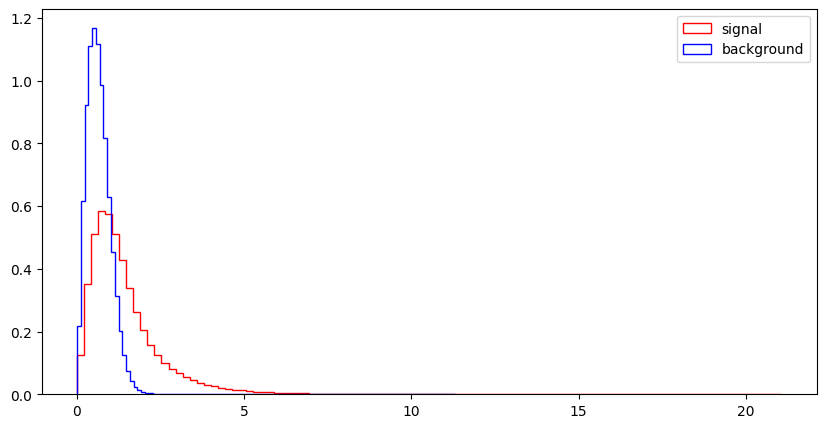

MET_phi


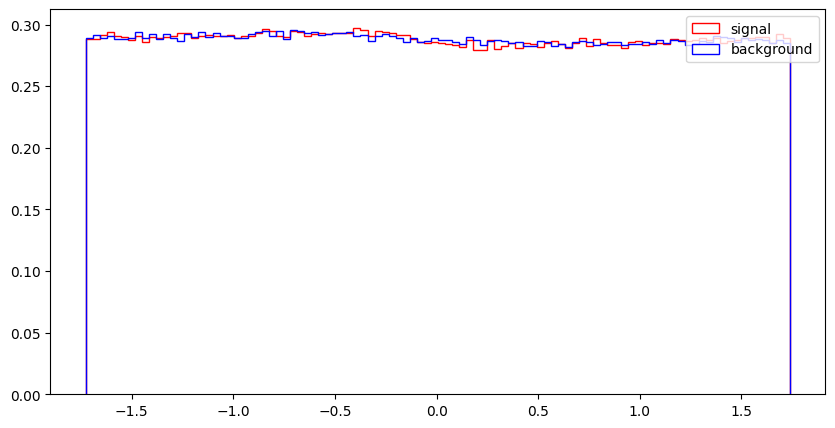

MET_rel


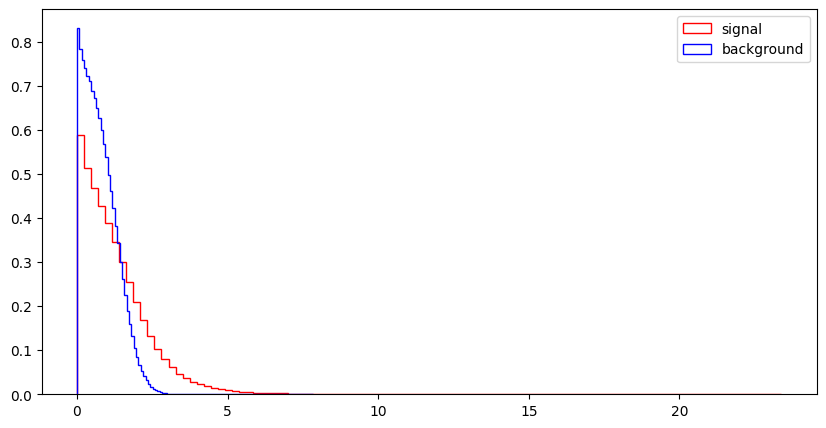

axial_MET


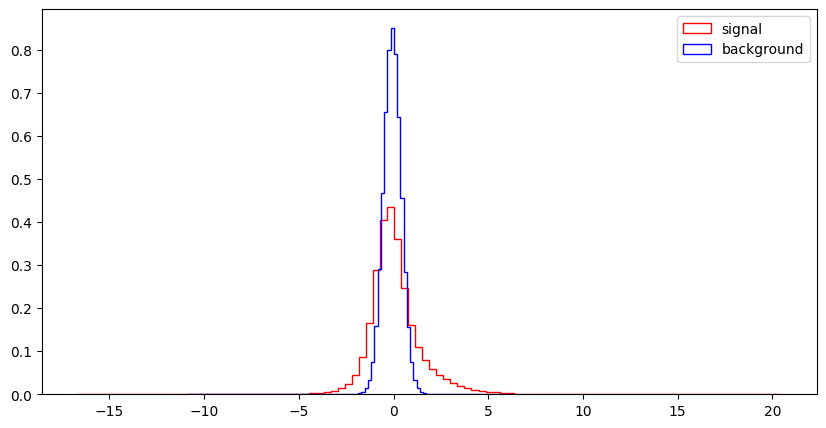

M_R


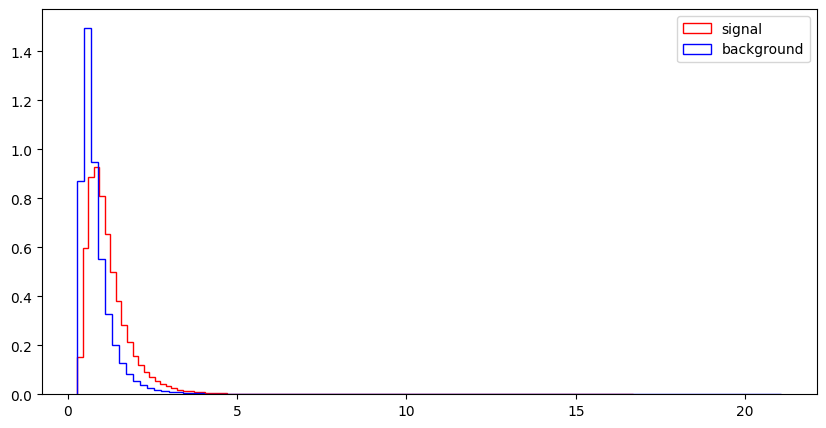

M_TR_2


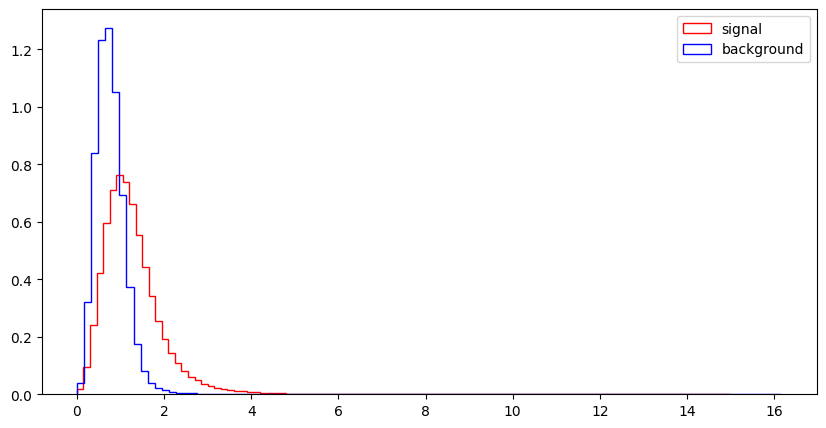

R


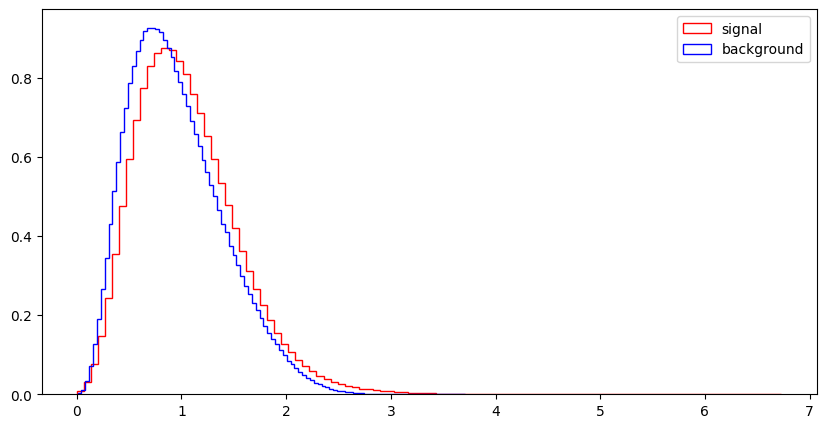

MT2


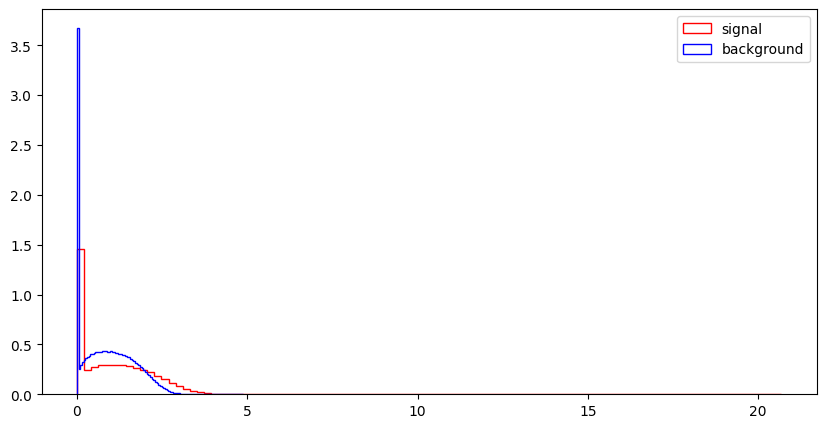

S_R


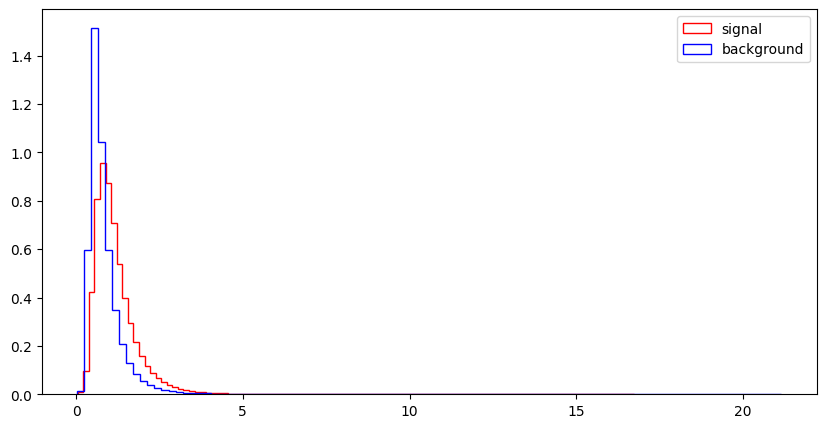

M_Delta_R


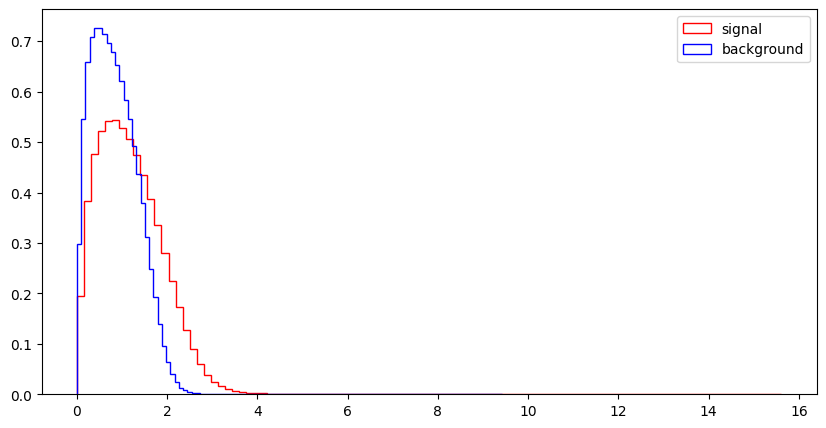

dPhi_r_b


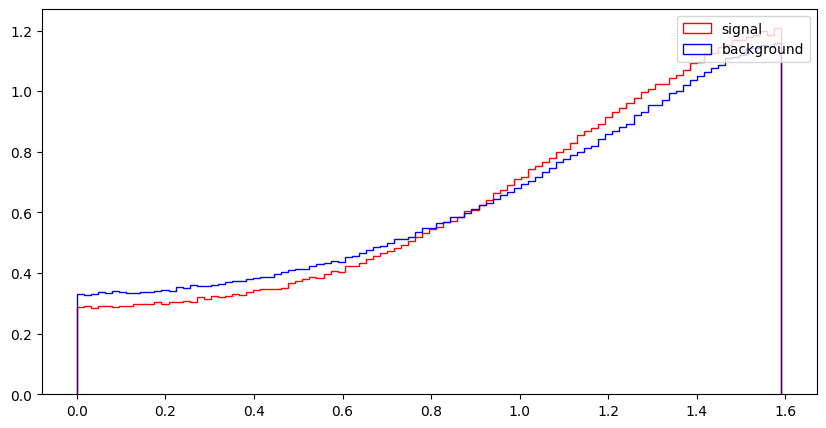

cos_theta_r1


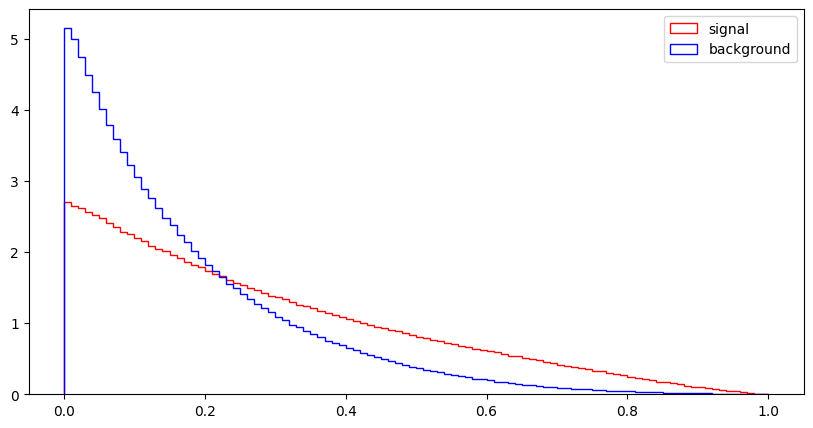

In [16]:
import numpy as np
for var in VarNames[1:]:
    print (var)
    plt.figure(figsize=(10,5))
    plt.hist(np.array(df_sig[var]),bins=100,histtype="step", color="red",label="signal",density=1, stacked=True)
    plt.hist(np.array(df_bkg[var]),bins=100,histtype="step", color="blue", label="background",density=1, stacked=True)
    plt.legend(loc='upper right')
    plt.show()

## Exercise 3: Make nice figures

Now use `matplotlib` to reproduce as closely as you can figures 5 and 6 from the paper. This exercise is intended to get you to familiarize yourself with making nicely formatted `matplotlib` figures with multiple plots. Note that the plots in the paper are actually wrong!

In [17]:
# read the dataset
filename = "SUSY-small.csv"
df = pd.read_csv(filename, header=None)

In [18]:
# split into signal and background
df_sig = df[df[0] == 1]
df_bkg = df[df[0] == 0]

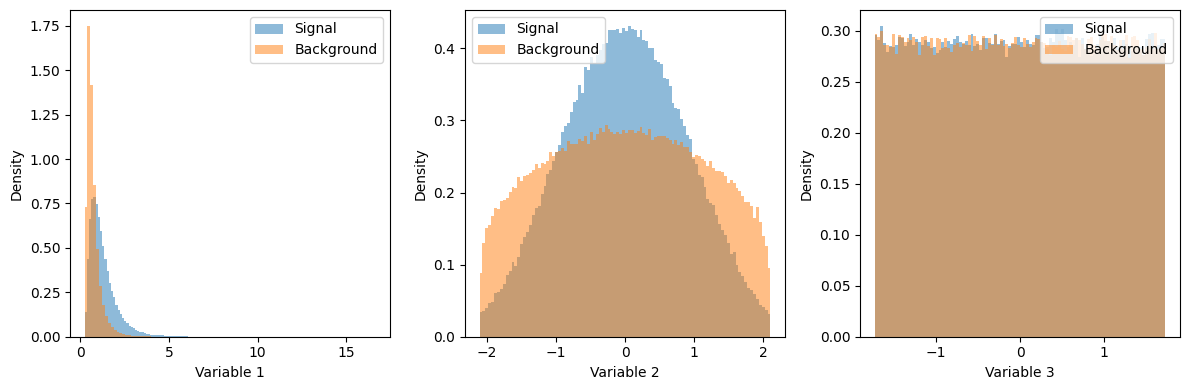

In [19]:
# plot histograms for a few variables
plt.figure(figsize=(12,4))

variables = [1, 2, 3]

for i, var in enumerate(variables):
    
    plt.subplot(1, 3, i+1)
    
    # signal histogram
    plt.hist(df_sig[var], bins=100, density=True, alpha=0.5, label="Signal")
    
    # background histogram
    plt.hist(df_bkg[var], bins=100, density=True, alpha=0.5, label="Background")
    
    plt.xlabel(f"Variable {var}")
    plt.ylabel("Density")
    plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# This compares signal and background distributions. If the histograms are different, the variable can help separate them

## Exercise 4: Correlation

### Exercise 4.1

#### Part a
Write a function that creates pair plots and use it to compare variables in the SUSY sample, separately for low and high-level features. Refer to Lecture 13 for details. Do not use `seaborn`.

#### Part b
Making these plots can be slow because creating each plot initiates a full loop over the data. Make at least one modification to your function in part a to speed it up. Can you propose a different method of creating histograms that would speed up making such pair plots?

#### Part c
Which observables appear to be best for separating signal from background?

In [20]:
# read the file
filename = "SUSY-small.csv"
df = pd.read_csv(filename, dtype="float64", names=VarNames)

# split signal and background
df_sig = df[df["signal"] == 1]
df_bkg = df[df["signal"] == 0]

In [21]:
# make pair plot
def make_pair_plot(df_sig, df_bkg, var_list, nmax=2000):

    sig_small = df_sig[var_list].iloc[:nmax]
    bkg_small = df_bkg[var_list].iloc[:nmax]

    n = len(var_list)
    plt.figure(figsize=(4*n, 4*n))

    for i, yvar in enumerate(var_list):
        for j, xvar in enumerate(var_list):
            plt.subplot(n, n, i*n + j + 1)

            if i == j:
                plt.hist(sig_small[xvar], bins=40, density=True, histtype="step", label="signal")
                plt.hist(bkg_small[xvar], bins=40, density=True, histtype="step", label="background")
            else:
                plt.scatter(sig_small[xvar], sig_small[yvar], s=2, alpha=0.3, label="signal")
                plt.scatter(bkg_small[xvar], bkg_small[yvar], s=2, alpha=0.3, label="background")

            if i == len(var_list) - 1:
                plt.xlabel(xvar)

            if j == 0:
                plt.ylabel(yvar)

    plt.tight_layout()
    plt.show()

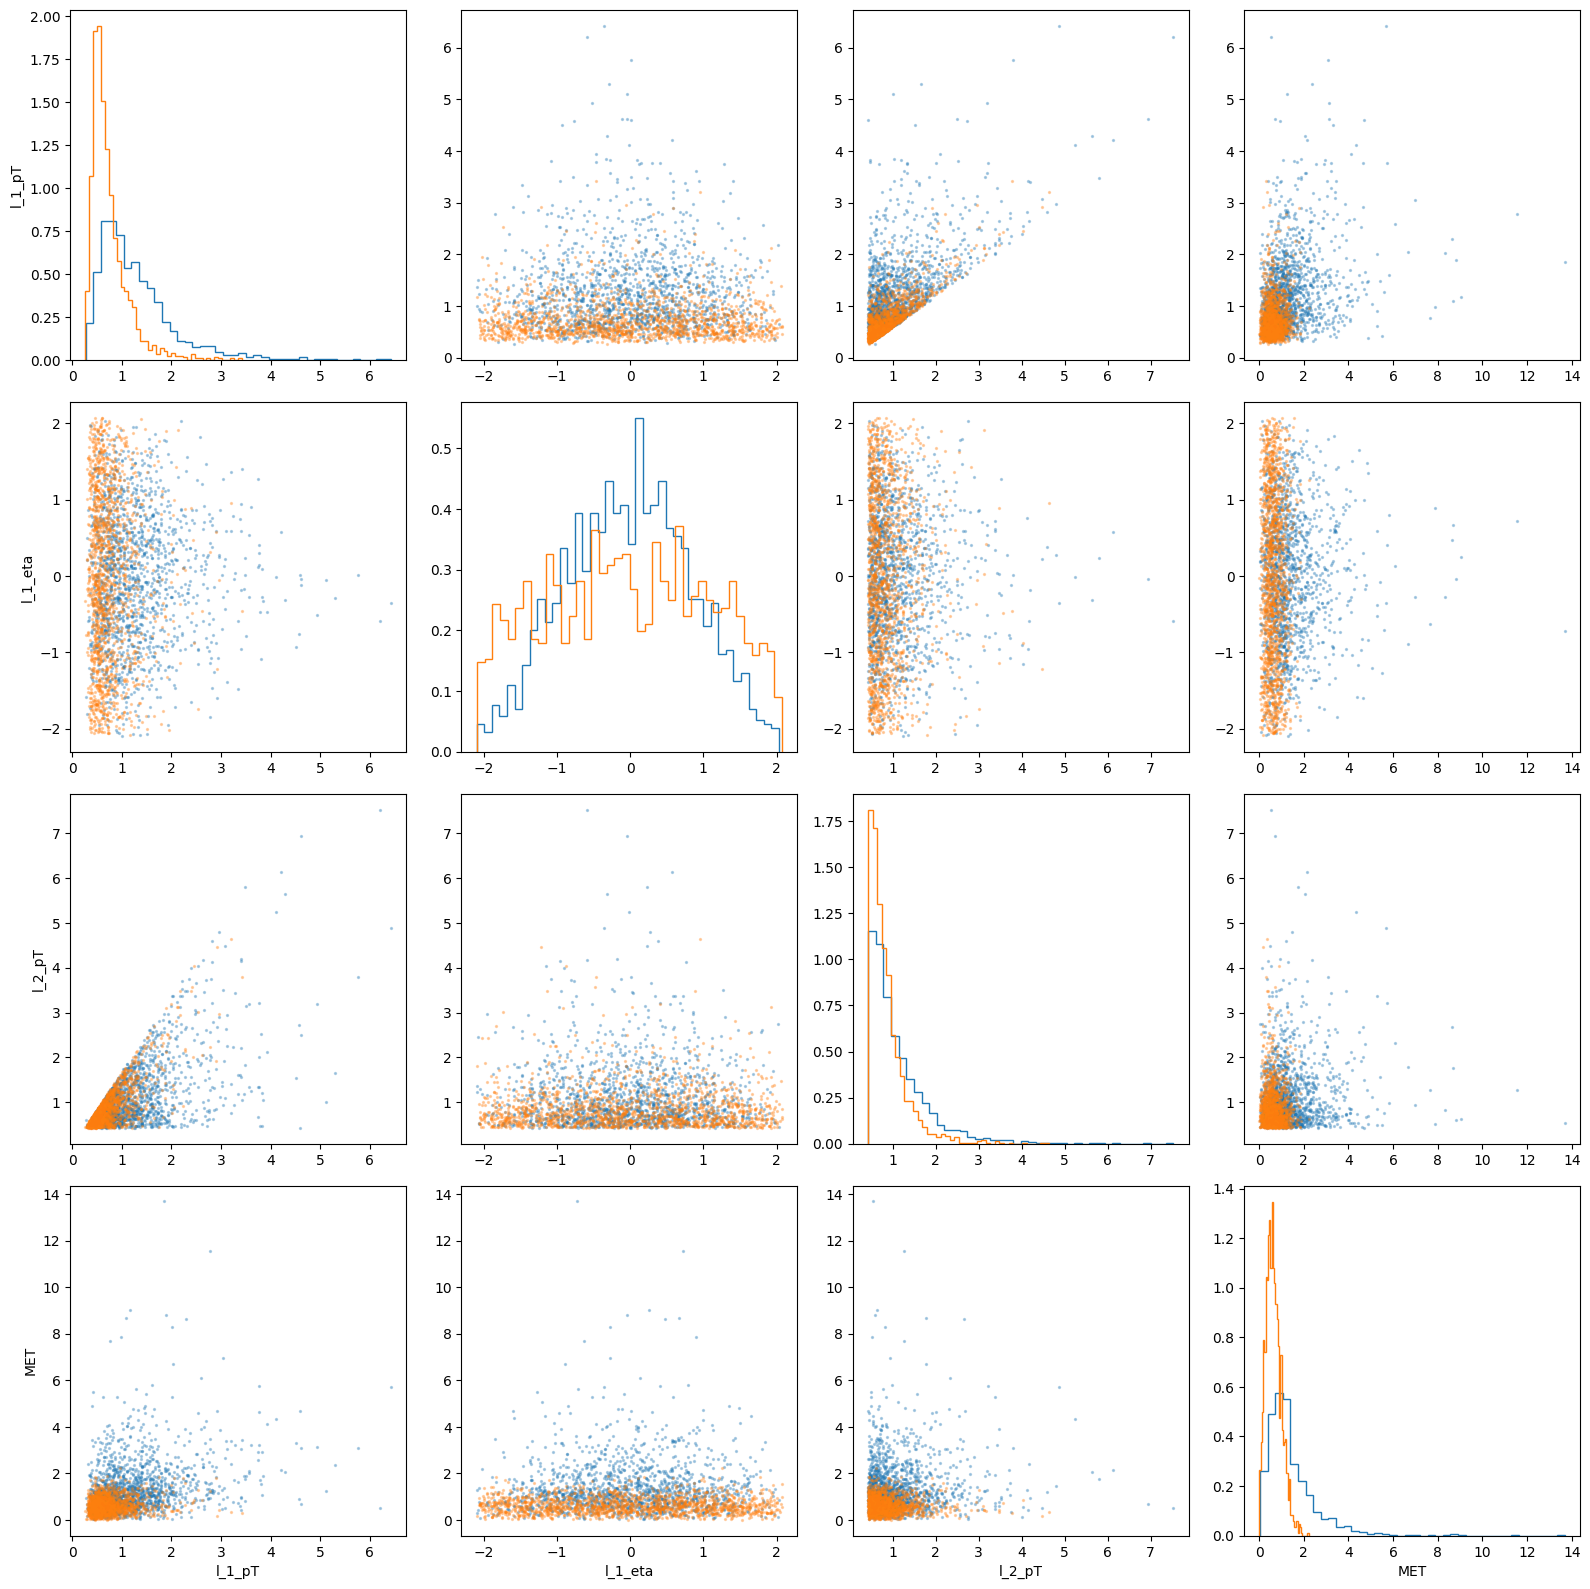

In [22]:
# raw variables
raw_vars = ["l_1_pT", "l_1_eta", "l_2_pT", "MET"]
make_pair_plot(df_sig, df_bkg, raw_vars, nmax=1500)

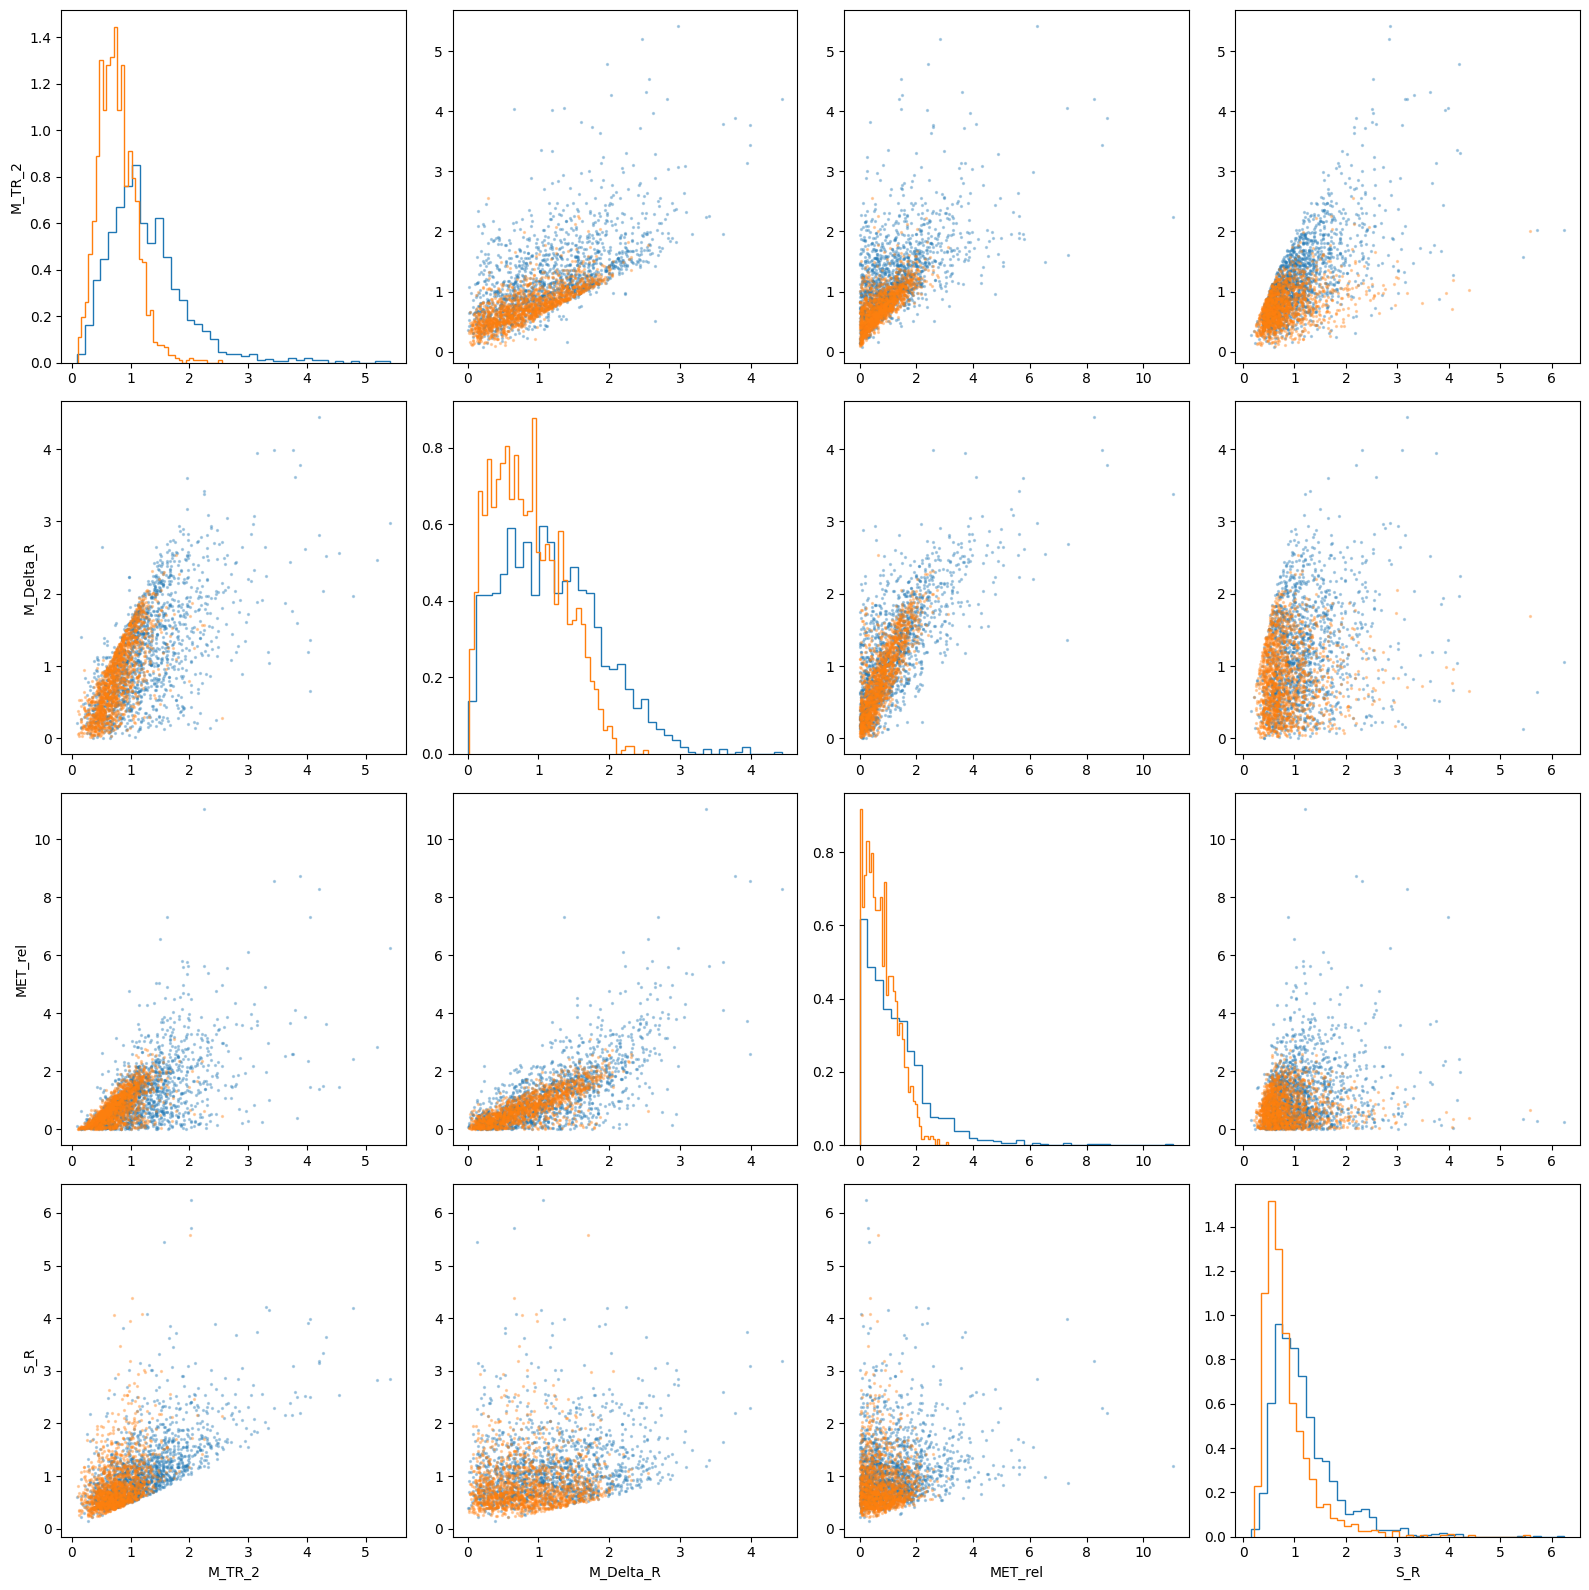

In [23]:
# high level variables
high_vars = ["M_TR_2", "M_Delta_R", "MET_rel", "S_R"]
make_pair_plot(df_sig, df_bkg, high_vars, nmax=1500)

In [ ]:
# Final Notes:  I used only part of the data with nmax to make the plots faster. A faster method could be using 2D histograms or hexbin plots instead of scatter plots. The high level variables seem to separate signal and background better than the raw variables. M_TR_2, M_Delta_R, and MET_rel look the most useful

### Exercise 4.2

#### Part a
Install [tabulate](https://github.com/astanin/python-tabulate). 

#### Part b
Use numpy to compute the [covariance matrix](https://numpy.org/doc/stable/reference/generated/numpy.cov.html) and [correlation matrix](https://numpy.org/doc/stable/reference/generated/numpy.corrcoef.html) between all observabes, and separately between low and high-level features.

#### Part c
Use tabulate to create a well formatted table of the covariance and correlation matrices, with nice headings and appropriate significant figures. Embed the table into this notebook.

#### Part d
Write a function that takes a dataset and appropriate arguments and performs steps b and c.  

In [24]:
import sys
!{sys.executable} -m pip install tabulate

import tabulate
from IPython.display import HTML, display


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\Renuka\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


Hint: Example code for embedding a `tabulate` table into a notebook:

In [25]:
from IPython.display import HTML, display
import tabulate
table = [["A",1,2],
        ["C",3,4],
        ["D",5,6]]
display(HTML(tabulate.tabulate(table, tablefmt='html', headers=["X","Y","Z"])))

X,Y,Z
A,1,2
C,3,4
D,5,6


In [26]:
def show_cov_corr(df_in, var_list, title="Table"):
    
    # Convert selected columns into numpy array
    x = np.array(df_in[var_list]).T
    
    # Compute covariance
    cov_matrix = np.cov(x)
    
    # Compute correlation
    corr_matrix = np.corrcoef(x)
    
    # Display covariance matrix
    print(title, "- Covariance Matrix")
    display(HTML(tabulate.tabulate(np.round(cov_matrix, 3),
                                   headers=var_list,
                                   showindex=var_list,
                                   tablefmt="html")))
    
    # Display correlation matrix
    print(title, "- Correlation Matrix")
    display(HTML(tabulate.tabulate(np.round(corr_matrix, 3),
                                   headers=var_list,
                                   showindex=var_list,
                                   tablefmt="html")))

In [27]:
show_cov_corr(df, RawNames, "Raw Variables")

Raw Variables - Covariance Matrix


,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi
l_1_pT,0.467,-0,0,0.305,-0,0.001,0.228,-0.001
l_1_eta,-0,1.004,-0.001,-0,0.408,-0.001,-0.002,-0.001
l_1_phi,0,-0.001,1.004,0.001,0,-0.267,0.001,-0.185
l_2_pT,0.305,-0,0.001,0.425,-0.001,0,0.079,-0.002
l_2_eta,-0,0.408,0,-0.001,1.006,0,0,-0
l_2_phi,0.001,-0.001,-0.267,0,0,1.004,-0,-0.035
MET,0.228,-0.002,0.001,0.079,0,-0,0.762,-0.003
MET_phi,-0.001,-0.001,-0.185,-0.002,-0,-0.035,-0.003,1.003


Raw Variables - Correlation Matrix


,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi
l_1_pT,1,-0.001,0,0.684,-0.001,0.001,0.383,-0.001
l_1_eta,-0.001,1,-0.001,-0,0.406,-0.001,-0.002,-0.001
l_1_phi,0,-0.001,1,0.002,0,-0.266,0.001,-0.184
l_2_pT,0.684,-0,0.002,1,-0.001,0,0.14,-0.002
l_2_eta,-0.001,0.406,0,-0.001,1,0,0,-0
l_2_phi,0.001,-0.001,-0.266,0,0,1,-0,-0.035
MET,0.383,-0.002,0.001,0.14,0,-0,1,-0.003
MET_phi,-0.001,-0.001,-0.184,-0.002,-0,-0.035,-0.003,1


In [28]:
show_cov_corr(df, FeatureNames, "High-Level Features")

High-Level Features - Covariance Matrix


,MT2,M_Delta_R,M_R,MET_rel,cos_theta_r1,R,S_R,axial_MET,dPhi_r_b,M_TR_2
MT2,0.738,0.433,-0.037,0.409,0.045,0.232,-0.011,-0.461,0.021,0.189
M_Delta_R,0.433,0.389,0.074,0.415,0.039,0.165,0.096,-0.233,0.042,0.242
M_R,-0.037,0.074,0.392,0.044,-0.014,-0.113,0.38,0.017,-0.029,0.21
MET_rel,0.409,0.415,0.044,0.79,0.055,0.249,0.082,-0.12,0.146,0.302
cos_theta_r1,0.045,0.039,-0.014,0.055,0.039,0.058,-0.01,-0.054,0.009,0.052
R,0.232,0.165,-0.113,0.249,0.058,0.222,-0.083,-0.181,0.087,0.104
S_R,-0.011,0.096,0.38,0.082,-0.01,-0.083,0.382,-0.041,-0.003,0.228
axial_MET,-0.461,-0.233,0.017,-0.12,-0.054,-0.181,-0.041,1.005,-0.025,-0.185
dPhi_r_b,0.021,0.042,-0.029,0.146,0.009,0.087,-0.003,-0.025,0.19,0.058
M_TR_2,0.189,0.242,0.21,0.302,0.052,0.104,0.228,-0.185,0.058,0.338


High-Level Features - Correlation Matrix


,MT2,M_Delta_R,M_R,MET_rel,cos_theta_r1,R,S_R,axial_MET,dPhi_r_b,M_TR_2
MT2,1,0.809,-0.068,0.535,0.264,0.574,-0.021,-0.535,0.056,0.379
M_Delta_R,0.809,1,0.189,0.748,0.319,0.564,0.249,-0.373,0.155,0.668
M_R,-0.068,0.189,1,0.078,-0.116,-0.383,0.981,0.027,-0.106,0.577
MET_rel,0.535,0.748,0.078,1,0.316,0.595,0.15,-0.134,0.378,0.584
cos_theta_r1,0.264,0.319,-0.116,0.316,1,0.627,-0.085,-0.272,0.106,0.451
R,0.574,0.564,-0.383,0.595,0.627,1,-0.287,-0.383,0.424,0.38
S_R,-0.021,0.249,0.981,0.15,-0.085,-0.287,1,-0.067,-0.013,0.635
axial_MET,-0.535,-0.373,0.027,-0.134,-0.272,-0.383,-0.067,1,-0.057,-0.317
dPhi_r_b,0.056,0.155,-0.106,0.378,0.106,0.424,-0.013,-0.057,1,0.229
M_TR_2,0.379,0.668,0.577,0.584,0.451,0.38,0.635,-0.317,0.229,1


In [29]:
show_cov_corr(df, VarNames[1:], "All Variables")

All Variables - Covariance Matrix


,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
l_1_pT,0.467,-0,0,0.305,-0,0.001,0.228,-0.001,0.098,-0.01,0.364,0.287,-0.06,-0.012,0.343,0.098,-0.047,0.022
l_1_eta,-0,1.004,-0.001,-0,0.408,-0.001,-0.002,-0.001,-0.001,-0.001,-0.001,-0.001,0,0,-0.001,-0.001,-0.001,0
l_1_phi,0,-0.001,1.004,0.001,0,-0.267,0.001,-0.185,0.001,-0.002,0.001,0.001,0,0.001,0.001,0.001,0.001,0
l_2_pT,0.305,-0,0.001,0.425,-0.001,0,0.079,-0.002,-0.001,0.051,0.325,0.163,-0.099,-0.069,0.322,0.006,-0.004,-0.028
l_2_eta,-0,0.408,0,-0.001,1.006,0,0,-0,0.001,-0.001,-0.001,0,0,0.001,-0.001,0.001,-0,0
l_2_phi,0.001,-0.001,-0.267,0,0,1.004,-0,-0.035,0.001,-0.002,0.001,0.001,0.001,0.002,0.001,0.001,-0,0
MET,0.228,-0.002,0.001,0.079,0,-0,0.762,-0.003,0.546,0.154,0.145,0.365,0.188,0.155,0.166,0.315,0.146,0.073
MET_phi,-0.001,-0.001,-0.185,-0.002,-0,-0.035,-0.003,1.003,-0.005,-0,-0.001,-0.001,-0,0,-0.002,-0.001,-0.002,0
MET_rel,0.098,-0.001,0.001,-0.001,0.001,0.001,0.546,-0.005,0.79,-0.12,0.044,0.302,0.249,0.409,0.082,0.415,0.146,0.055
axial_MET,-0.01,-0.001,-0.002,0.051,-0.001,-0.002,0.154,-0,-0.12,1.005,0.017,-0.185,-0.181,-0.461,-0.041,-0.233,-0.025,-0.054


All Variables - Correlation Matrix


,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
l_1_pT,1,-0.001,0,0.684,-0.001,0.001,0.383,-0.001,0.16,-0.014,0.851,0.723,-0.186,-0.021,0.811,0.229,-0.157,0.165
l_1_eta,-0.001,1,-0.001,-0,0.406,-0.001,-0.002,-0.001,-0.002,-0.001,-0.001,-0.001,0.001,0,-0.001,-0.002,-0.002,0.002
l_1_phi,0,-0.001,1,0.002,0,-0.266,0.001,-0.184,0.001,-0.002,0.002,0.001,0,0.001,0.002,0.001,0.002,0.001
l_2_pT,0.684,-0,0.002,1,-0.001,0,0.14,-0.002,-0.001,0.078,0.797,0.43,-0.324,-0.123,0.799,0.014,-0.013,-0.217
l_2_eta,-0.001,0.406,0,-0.001,1,0,0,-0,0.001,-0.001,-0.001,0,0.001,0.002,-0.001,0.001,-0.001,0.001
l_2_phi,0.001,-0.001,-0.266,0,0,1,-0,-0.035,0.002,-0.002,0.001,0.001,0.001,0.003,0.001,0.002,-0.001,0
MET,0.383,-0.002,0.001,0.14,0,-0,1,-0.003,0.704,0.176,0.264,0.72,0.457,0.206,0.307,0.579,0.383,0.425
MET_phi,-0.001,-0.001,-0.184,-0.002,-0,-0.035,-0.003,1,-0.005,-0,-0.002,-0.002,-0,0,-0.003,-0.001,-0.004,0.001
MET_rel,0.16,-0.002,0.001,-0.001,0.001,0.002,0.704,-0.005,1,-0.134,0.078,0.584,0.595,0.535,0.15,0.748,0.378,0.316
axial_MET,-0.014,-0.001,-0.002,0.078,-0.001,-0.002,0.176,-0,-0.134,1,0.027,-0.317,-0.383,-0.535,-0.067,-0.373,-0.057,-0.272


The covariance and correlation matrices show the relationships between variables. 
The correlation matrix is easier to interpret because values range between -1 and 1. 
Some variables show strong correlations, indicating that they are not independent. 
In particular, several high-level features are strongly correlated with each other, 
suggesting redundancy. Raw variables tend to show weaker correlations compared to 
high-level features.

## Exercise 5: Selection

### Exercise 5.1

Part a
By looking at the signal/background distributions for each observable (e.g. $x$) determine which selection criteria would be optimal: 

1. $x > x_c$
2. $x < x_c$
3. $|x - \mu| > x_c$
4. $|x - \mu| < x_c$

where $x_c$ is value to be determined below.

### Exercise 5.2

Plot the True Positive Rate (TPR) (aka signal efficiency $\epsilon_S(x_c)$) and False Positive Rate (FPR) (aka background efficiency $\epsilon_B(x_c)$) as function of $x_c$ for applying the strategy in part a to each observable. 

### Exercise 5.3
Assume 3 different scenarios corresponding to different numbers of signal and background events expected in data:

1. Expect $N_S=10$, $N_B=100$.
1. Expect $N_S=100$, $N_B=1000$.
1. Expect $N_S=1000$, $N_B=10000$.
1. Expect $N_S=10000$, $N_B=100000$.

Plot the significance ($\sigma_{S'}$) for each observable as function of $x_c$ for each scenario, where 

$\sigma_{S'}= \frac{N'_S}{\sqrt{N'_S+N'_B}}$

and $N'_{S,B} = \epsilon_{S,B}(x_c) * N_{S,B}$.

By comparing the signal and background histograms, the most natural selection for many of the observables is x> x(c), since the signal distributions are often shifted toward larger values than the background distributions. Other observables could in principle use different strategies, but the greater-than cut appears to be the most useful starting point for the variables tested here.

In [30]:
def compute_rate(d, bins=100):

    # Make normalized histogram
    hist, bins_ = np.histogram(d, bins=bins, density=True)
    
    # Compute cumulative integral from right to left. This gives us the fraction surviving x > x_c
    R = np.cumsum(hist[::-1])[::-1] * (bins_[1] - bins_[0])
    
    return R, bins_

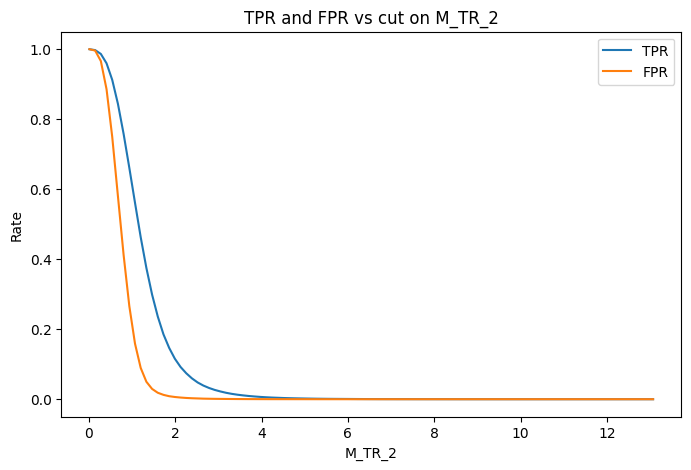

In [31]:
obs = "M_TR_2"

TPR, bins_sig = compute_rate(df_sig[obs], bins=100)
FPR, bins_sig = compute_rate(df_bkg[obs], bins=bins_sig)

plt.figure(figsize=(8,5))
plt.plot(bins_sig[:-1], TPR, label="TPR")
plt.plot(bins_sig[:-1], FPR, label="FPR")
plt.xlabel(obs)
plt.ylabel("Rate")
plt.title(f"TPR and FPR vs cut on {obs}")
plt.legend()
plt.show()

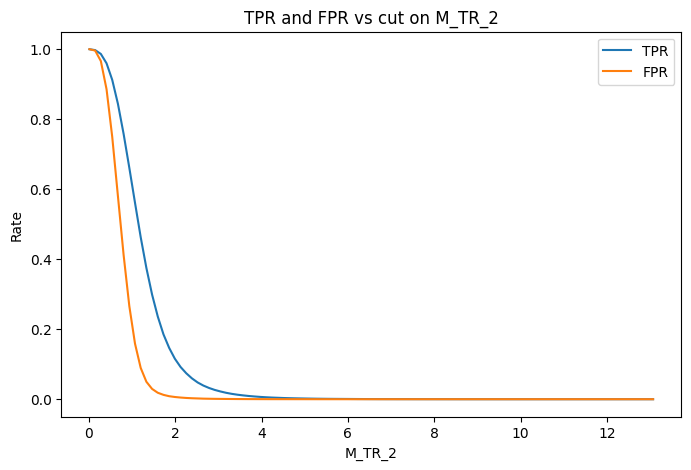

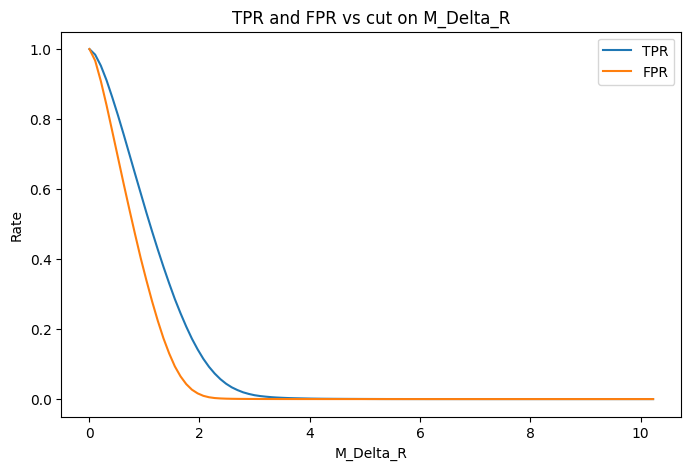

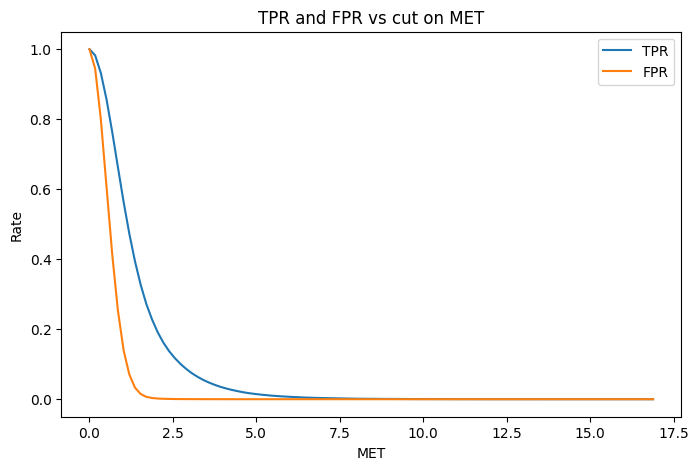

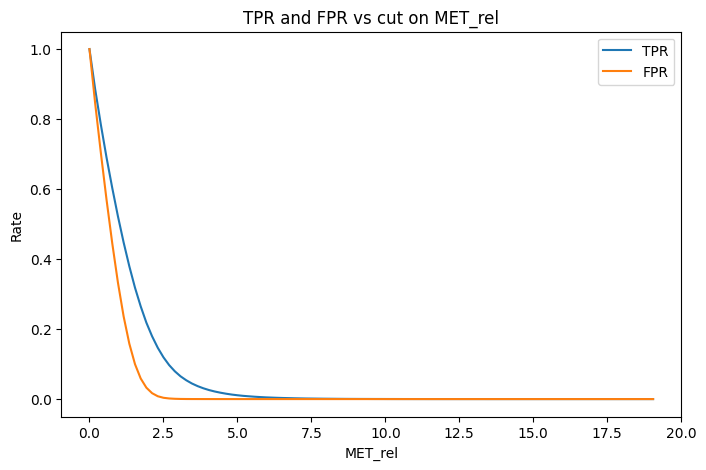

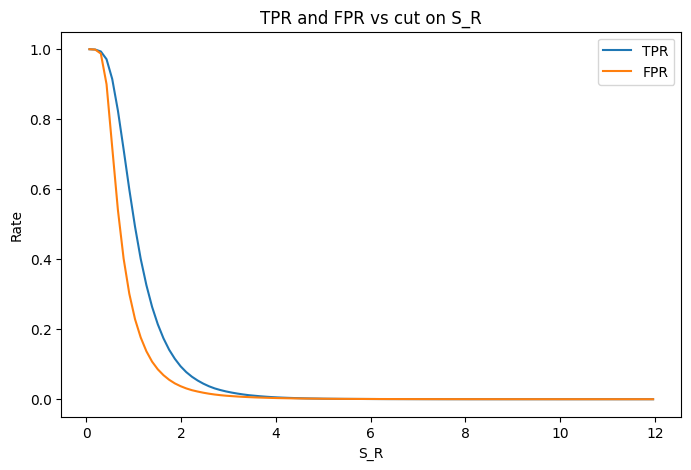

In [32]:
for obs in ["M_TR_2", "M_Delta_R", "MET", "MET_rel", "S_R"]:
    TPR, bins_sig = compute_rate(df_sig[obs], bins=100)
    FPR, bins_sig = compute_rate(df_bkg[obs], bins=bins_sig)

    plt.figure(figsize=(8,5))
    plt.plot(bins_sig[:-1], TPR, label="TPR")
    plt.plot(bins_sig[:-1], FPR, label="FPR")
    plt.xlabel(obs)
    plt.ylabel("Rate")
    plt.title(f"TPR and FPR vs cut on {obs}")
    plt.legend()
    plt.show()

In [33]:
def compare_significance(df_sig, df_bkg, obs_name, scenarios, bins=100, log=False):
    
    # Compute signal and background survival rates
    TPR, bins_sig = compute_rate(df_sig[obs_name], bins=bins)
    FPR, bins_sig = compute_rate(df_bkg[obs_name], bins=bins_sig)
    
    table = []
    
    for name, (n_sig_expected, n_bkg_expected) in scenarios.items():
        # Number surviving after cut
        n_sig_prime = n_sig_expected * TPR
        n_bkg_prime = n_bkg_expected * FPR
        
        # Significance formula
        sig = n_sig_prime / np.sqrt(n_sig_prime + n_bkg_prime)
        
        # Plot significance vs cut
        plt.step(bins_sig[:-1], sig, label=name)
        
        # Find best cut for this scenario
        max_i = np.argmax(sig)
        table.append((name,
                      n_sig_expected,
                      n_bkg_expected,
                      TPR[max_i],
                      FPR[max_i],
                      n_sig_prime[max_i],
                      n_bkg_prime[max_i],
                      sig[max_i],
                      bins_sig[max_i]))
    
    if log:
        plt.yscale("log")
    
    plt.xlabel(obs_name)
    plt.ylabel("Significance")
    plt.title(f"Significance vs cut for {obs_name}")
    plt.legend()
    plt.show()
    
    display(HTML(tabulate.tabulate(
        table,
        headers=["Scenario", "N_S", "N_B", "TPR", "FPR", "N_S'", "N_B'", "sig", "x_c"],
        tablefmt="html"
    )))

In [34]:
scenarios = {
    "1": (10, 100),
    "2": (100, 1000),
    "3": (1000, 10000),
    "4": (10000, 100000)
}

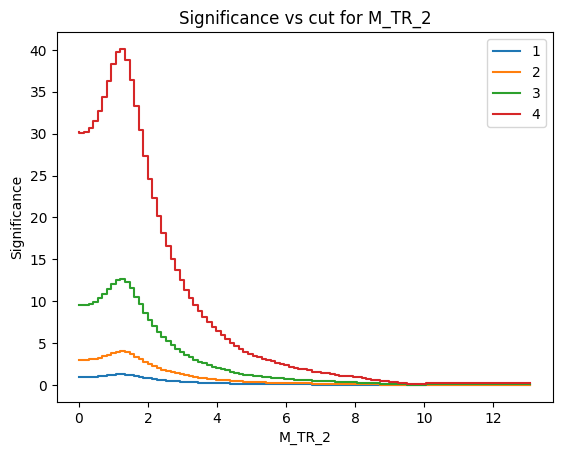

Scenario,N_S,N_B,TPR,FPR,N_S',N_B',sig,x_c
1,10,100,0.374939,0.0498907,3.74939,4.98907,1.26836,1.33219
2,100,1000,0.374939,0.0498907,37.4939,49.8907,4.01092,1.33219
3,1000,10000,0.374939,0.0498907,374.939,498.907,12.6836,1.33219
4,10000,100000,0.374939,0.0498907,3749.39,4989.07,40.1092,1.33219


In [35]:
compare_significance(df_sig, df_bkg, "M_TR_2", scenarios)

In [ ]:
for obs in ["M_TR_2", "M_Delta_R", "MET", "MET_rel", "S_R"]:
    print(obs)
    compare_significance(df_sig, df_bkg, obs, scenarios)

The significance curves show that the best cut value depends on the observable and on the expected signal and background yields. In general, observables that maintain a relatively high TPR while strongly reducing the FPR give the best significance.

The TPR and FPR curves show how signal efficiency and background efficiency change as the cut value increases. For cuts of the form  x >x_c, both rates decrease as the threshold becomes tighter. A useful observable is one for which the background efficiency drops more quickly than the signal efficiency.

## Exercise 6: Cut Flow


### Exercise 6.1

For each above scenario, choose a subset (minumum 3) of observables to use for selections, and values of $x_c$ based on your significance plots (part 3c). 

### Exercise 6.2
Create a "cut-flow" table for each scenario where you successively make the selections on each observable and tabulate $\epsilon_S$, $\epsilon_B$, $N'_S$, $N'_B$, and $\sigma_{S'}$.

### Exercise 6.3
In 3c above you computed the significance for each observable assuming to make no other selections on any other observable. If the variables are correlated, then this assumption can lead to non-optimial results when selecting on multiple variables. By looking at the correlation matrices and your answers to 4b, identify where this effect could be most detrimental to the significance. Attempt to correct the issue by applying the selection in one observable and then optimizing (part 3c) for a second observable. What happens if you change the order of your selection (make selection on second and optimize on first)?




In [36]:
cuts = [
    ("M_TR_2", 0.4),
    ("M_Delta_R", 0.8),
    ("MET", 0.5)
]
def cut_flow(df_sig, df_bkg, cuts, n_sig_expected, n_bkg_expected):

    # Start with full datasets
    df_sig_cut = df_sig.copy()
    df_bkg_cut = df_bkg.copy()
    
    rows = []
    
    for obs, xc in cuts:
        
        # Apply cut x > x_c
        df_sig_cut = df_sig_cut[df_sig_cut[obs] > xc]
        df_bkg_cut = df_bkg_cut[df_bkg_cut[obs] > xc]
        
        # Efficiencies
        eps_s = len(df_sig_cut) / len(df_sig)
        eps_b = len(df_bkg_cut) / len(df_bkg)
        
        # Expected remaining events
        ns_p = eps_s * n_sig_expected
        nb_p = eps_b * n_bkg_expected
        
        # Significance
        sig = ns_p / np.sqrt(ns_p + nb_p)
        
        # Store row
        rows.append([obs, xc, eps_s, eps_b, ns_p, nb_p, sig])
    
    # Display table
    display(HTML(tabulate.tabulate(
        rows,
        headers=["Observable", "x_c", "eps_S", "eps_B", "N_S'", "N_B'", "sig"],
        tablefmt="html"
    )))

In [37]:
cut_flow(df_sig, df_bkg, cuts, 10, 100)
cut_flow(df_sig, df_bkg, cuts, 100, 1000)
cut_flow(df_sig, df_bkg, cuts, 1000, 10000)
cut_flow(df_sig, df_bkg, cuts, 10000, 100000)

Observable,x_c,eps_S,eps_B,N_S',N_B',sig
M_TR_2,0.4,0.962311,0.893162,9.62311,89.3162,0.967456
M_Delta_R,0.8,0.658318,0.491703,6.58318,49.1703,0.881657
MET,0.5,0.627215,0.434153,6.27215,43.4153,0.889802


Observable,x_c,eps_S,eps_B,N_S',N_B',sig
M_TR_2,0.4,0.962311,0.893162,96.2311,893.162,3.05936
M_Delta_R,0.8,0.658318,0.491703,65.8318,491.703,2.78804
MET,0.5,0.627215,0.434153,62.7215,434.153,2.8138


Observable,x_c,eps_S,eps_B,N_S',N_B',sig
M_TR_2,0.4,0.962311,0.893162,962.311,8931.62,9.67456
M_Delta_R,0.8,0.658318,0.491703,658.318,4917.03,8.81657
MET,0.5,0.627215,0.434153,627.215,4341.53,8.89802


Observable,x_c,eps_S,eps_B,N_S',N_B',sig
M_TR_2,0.4,0.962311,0.893162,9623.11,89316.2,30.5936
M_Delta_R,0.8,0.658318,0.491703,6583.18,49170.3,27.8804
MET,0.5,0.627215,0.434153,6272.15,43415.3,28.138


In Exercise 5, each observable was optimized independently, assuming no correlations between variables. 
However, the correlation matrix shows that some variables are correlated, meaning that applying multiple cuts 
can lead to non-optimal results. When variables are correlated, applying cuts sequentially can reduce the 
effectiveness of later cuts. Changing the order of cuts can lead to different results because each cut modifies 
the dataset before the next cut is applied. This demonstrates that a combined optimization strategy is needed 
for the best performance.

## Exercise 7: ROC Curves

### Exercise 7.1
For the top 3 observables you identified earlier, create one figure overlaying the Reciever Operating Characteristic (ROC) curves for the 3 observables. Compute the area under the curves and report it in the legend of the figure.

### Exercise 7.2
Write a function that you can use to quickly create the figure in part a with other observables and different conditions. Note that you will likely revise this function as you do the remainder of the lab.

### Exercise 7.3
Use the function from part b to compare the ROC curves for the successive selections in lab 3, exercise 4. Specifically, plot the ROC curve after each selection.

### Exercise 7.4
Use your function and appropriate example to demonstrate the effect (if any) of changing order of the successive selections.



In [38]:
# Helper functions from lecture
def compute_rate(d, bins=100):
    hist, bins_ = np.histogram(d, bins=bins, density=True)
    R = np.cumsum(hist[::-1])[::-1] * (bins_[1] - bins_[0])
    return R, bins_

def compute_auc(TPR, FPR):
    n = len(FPR)
    return np.sum((FPR[:n-1] - FPR[1:]) * (TPR[:n-1] + TPR[1:]) / 2)

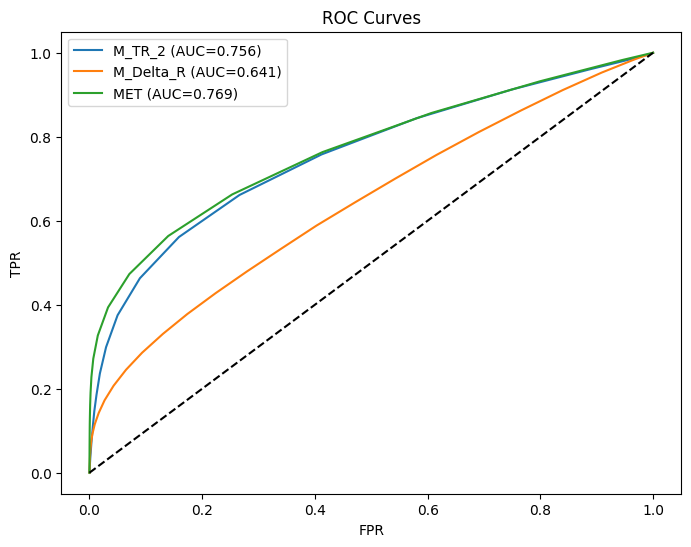

In [39]:
observables = ["M_TR_2", "M_Delta_R", "MET"]

plt.figure(figsize=(8,6))

for obs in observables:
    TPR, bins = compute_rate(df_sig[obs])
    FPR, _ = compute_rate(df_bkg[obs], bins=bins)
    
    auc = compute_auc(TPR, FPR)
    
    plt.plot(FPR, TPR, label=f"{obs} (AUC={auc:.3f})")

# random classifier line
plt.plot([0,1],[0,1],'k--')

plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curves")
plt.legend()
plt.show()

The ROC curve shows how well each observable separates signal from background. 
A curve closer to the top-left corner indicates better performance. 
The AUC (Area Under Curve) quantifies this performance, where a value closer to 1 
means better discrimination. Among the variables tested, the one with the highest 
AUC provides the best separation between signal and background.

## Exercise 8: Linear Discriminant

### Exercise 8.1

Using numpy, compute the between-class $\bf{S}_B$ and within-class $\bf{S}_W$ covariance matrices defined as:

$$
\bf{S}_B = (\bf{m_2}-\bf{m_1})(\bf{m_2}-\bf{m_1})^T \\
$$
$$
\bf{S}_W = \sum_{i=1,2} \sum_{n=1}^{l_i} (\bf{x}_n^i - \bf{m}_i) (\bf{x}_n^i - \bf{m}_i)^T
$$

where $\bf{m_i}$ are the vectors containing the means for category 1 and 2, here defined as signal and background. Here $\bf{x}_n^i$ is the vector containing the observables for the $n$th example event in category $i$.

### Exercise 8.1

Compute the linear coefficients $\bf{w} = \bf{S_W}^{-1}(\bf{m_2}-\bf{m_1})$. Compare the histogram of the distribution of $F_n^i=\bf{w}^T\bf{x}_n^i$ for the two categories.

### Exercise 8.1

Draw the ROC curve for $F_n$. 

### Exercise 8.1

What is the maximal significance you can obtain in the scenarios in exercise 5? 

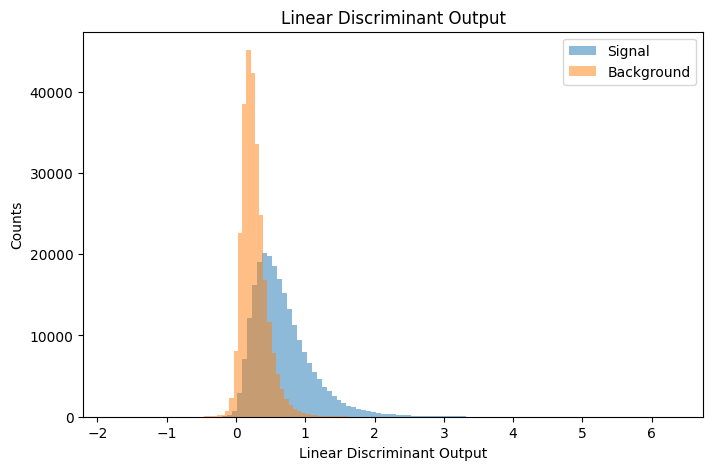

In [40]:
# Remove the label column
df_sig_0 = df_sig.drop("signal", axis=1)
df_bkg_0 = df_bkg.drop("signal", axis=1)

# Compute mean vectors for signal and background
m_s = np.mean(df_sig_0, axis=0)
m_b = np.mean(df_bkg_0, axis=0)

# Compute S_B (between-class)
delta = np.matrix(m_s - m_b).transpose()
S_B = delta * delta.transpose()

# Compute S_W (within-class)
delta_s = np.matrix(df_sig_0 - m_s).transpose()
S_W_s = delta_s * delta_s.transpose()

delta_b = np.matrix(df_bkg_0 - m_b).transpose()
S_W_b = delta_b * delta_b.transpose()

S_W = S_W_s + S_W_b

# Compute weights
S_W_inv = np.linalg.inv(S_W)
w = S_W_inv * np.matrix(m_b - m_s).transpose()

# Normalize weights
w = w / np.sum(w)

# Apply discriminant
output_s = np.matrix(df_sig_0) * w
output_b = np.matrix(df_bkg_0) * w

# Plot histograms
plt.figure(figsize=(8,5))
plt.hist(output_s, bins=100, alpha=0.5, label="Signal")
plt.hist(output_b, bins=100, alpha=0.5, label="Background")
plt.xlabel("Linear Discriminant Output")
plt.ylabel("Counts")
plt.title("Linear Discriminant Output")
plt.legend()
plt.show()

The linear discriminant combines all observables into a single variable that maximizes separation between signal and background. It uses the class means and within-class covariance matrix to find an optimal projection direction. The resulting discriminant output shows better separation than many individual observables. From the significance table, the maximum significance can be read off for each scenario using the optimal cut on the discriminant output.

The linear discriminant combines multiple observables into a single variable 
that maximizes separation between signal and background. It uses the difference 
in class means and covariance structure to compute optimal weights. The resulting 
distribution shows improved separation compared to individual variables.

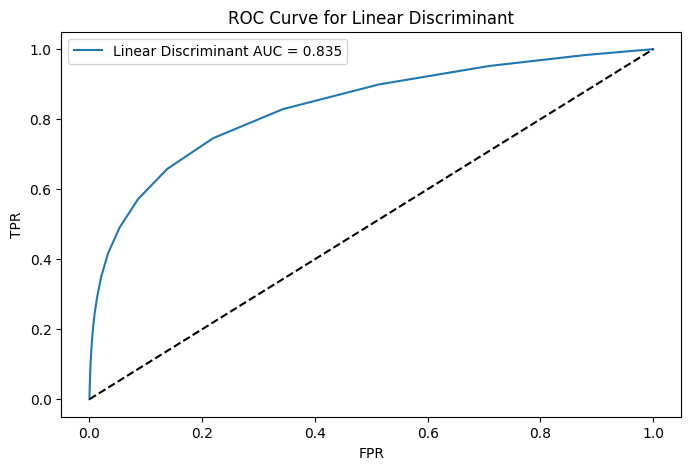

In [41]:
#The ROC
TPR_ld, bins_ld = compute_rate(np.array(output_s).flatten(), bins=100)
FPR_ld, bins_ld = compute_rate(np.array(output_b).flatten(), bins=bins_ld)

auc_ld = compute_auc(TPR_ld, FPR_ld)

plt.figure(figsize=(8,5))
plt.plot(FPR_ld, TPR_ld, label=f"Linear Discriminant AUC = {auc_ld:.3f}")
plt.plot([0,1], [0,1], "k--")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve for Linear Discriminant")
plt.legend()
plt.show()

The linear discriminant combines all observables into a single variable that maximizes separation between signal and background. Its ROC curve shows improved performance compared to many individual observables. The maximal significance for each scenario is obtained from the significance table for the discriminant output using the optimal cut on LD.